## Project: Stock Market Analysis and Prediction
### Stock Market Data From Google Finance
### Introduction
Stock Market Analysis and Prediction is the technical analysis, visualization, and prediction project based on data provided by Google Finance. By examining data from the stock market, especially some behemoth technology stocks and others. Utilized pandas to retrieve stock data, plot various attributes of it, and lastly examined several approaches to analyzing the risk of a stock, according to its past performance record. Estimated future stock prices using a Monte Carlo approach!
### For this analysis, I would like to address the following questions.
1. How did the price change of the stock over time?
2. What was the average daily return of the stock?
3. What was the moving average of the different stocks?
4. How correlated were different stocks' closing prices?
4. How correlated were different stocks' daily returns?
5. How much do we risk in value by betting on a specific stock?
6. How do we try to forecast future stock behavior?

In [ ]:
%pip install -r https://raw.githubusercontent.com/brittojo7n/BigDataProject-StockMarketTrendAnalysisAndPrediction/refs/heads/main/requirements.txt

In [ ]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline


In [ ]:
from pandas_datareader import DataReader
from datetime import datetime
from __future__ import division

#### Section 1 - Basic Analysis of Stock Information


In this section I'll go over how to handle requesting stock information with pandas, and how to analyze basic attributes of a stock.


In [ ]:
%pip install yfinance

In [ ]:
import yfinance as yf
from datetime import datetime, timedelta
import time

tech_list = ['AAPL', 'GOOGL', 'MSFT', 'AMZN']

end = datetime.now()
start = end - timedelta(days=365*5)

stock_data = {}

for stock in tech_list:
    success = False
    for attempt in range(3):
        try:
            print(f"Fetching data for {stock} (Attempt {attempt + 1})...")
            data = yf.download(stock, start=start, end=end, threads=False)
            if not data.empty:
                stock_data[stock] = data
                success = True
                break
            else:
                print(f"No data returned for {stock}, retrying...")
        except Exception as e:
            print(f"Error fetching data for {stock}: {e}")
        time.sleep(5)

    if not success:
        print(f"Failed to fetch data for {stock} after 3 attempts.")

AAPL = stock_data.get('AAPL')
if AAPL is not None:
    print("\nAAPL Stock Data:")
    print(AAPL.head())
else:
    print("\nData for AAPL is not available.")

[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['GOOGL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['MSFT']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['AMZN']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


AAPL Stock Data:
Empty DataFrame
Columns: [(Adj Close, AAPL), (Close, AAPL), (High, AAPL), (Low, AAPL), (Open, AAPL), (Volume, AAPL)]
Index: []


Quick note: Using globals() is a sloppy way of setting the DataFrame names, but its simple

Let's go ahead and play aorund with the AAPL(Apple) Stock DataFrame to get a feel for the data.

In [ ]:
AAPL.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-04-30,169.529510,174.167614,169.201060,172.515412,65934800
2024-05-01,168.504349,171.898327,168.315239,168.783032,50383100
2024-05-02,172.216827,172.604994,170.086885,171.699267,94214900
2024-05-03,182.518173,186.121155,181.801556,185.772794,163224100
2024-05-06,180.856049,183.334337,179.572103,181.493040,78569700


In [ ]:
AAPL.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02
mean,221.510816,223.765939,218.899412,221.150785,5.666649e+07
std,18.327759,17.996432,18.477388,18.415757,3.314105e+07
min,168.504349,171.898327,168.315239,168.783032,2.323470e+07
25%,213.409634,215.515666,210.666978,213.153619,3.964202e+07
50%,224.504585,226.366475,222.522797,224.464611,4.804335e+07
75%,232.820576,234.570783,229.482695,232.752745,6.076482e+07
max,258.735504,259.814335,257.347047,257.906429,3.186799e+08


In [ ]:
AAPL.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2024-04-30 to 2025-04-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   250 non-null    float64
 1   (High, AAPL)    250 non-null    float64
 2   (Low, AAPL)     250 non-null    float64
 3   (Open, AAPL)    250 non-null    float64
 4   (Volume, AAPL)  250 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.7 KB


Now that we've seen the DataFrame, let's go ahead and plot out the volume and closing price of the AAPL(Apple) stocks.

<Axes: xlabel='Date'>

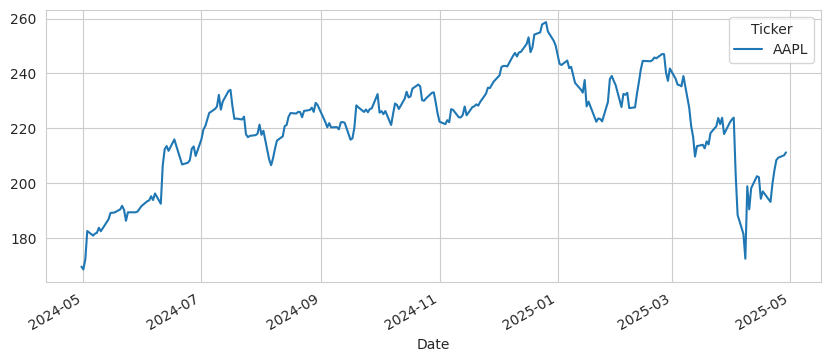

In [ ]:
AAPL['Close'].plot(legend=True, figsize=(10,4))

<Axes: xlabel='Date'>

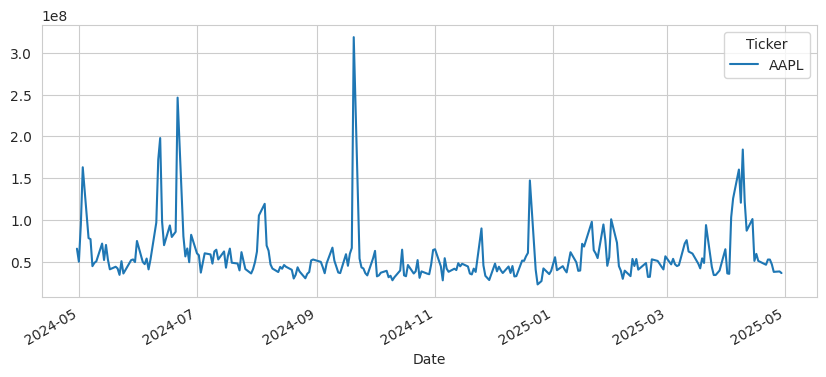

In [ ]:
AAPL['Volume'].plot(legend=True, figsize=(10,4))

We can see that on Feb'2017 was the higher for AAPL stock being traded.

Now that we've seen the visualizations for the closing price and the volume traded each day for AAPL stock.
Let's go ahead and caculate the moving average for the AAPL stock.


For more info on the Moving Average(SMA & EMA) check out the following links:

1.) http://www.investopedia.com/terms/m/movingaverage.asp

2.) http://www.investopedia.com/articles/active-trading/052014/how-use-moving-average-buy-stocks.asp

In [ ]:
import pandas as pd

MA_day = [10, 20, 50, 100]

for ma in MA_day:
    column_name = f"MA for {ma} days"
    AAPL[column_name] = AAPL['Close'].rolling(window=ma).mean()

print(AAPL.head())


Price            Close        High         Low        Open     Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL   
Date                                                                    
2024-04-30  169.529510  174.167614  169.201060  172.515412   65934800   
2024-05-01  168.504349  171.898327  168.315239  168.783032   50383100   
2024-05-02  172.216827  172.604994  170.086885  171.699267   94214900   
2024-05-03  182.518173  186.121155  181.801556  185.772794  163224100   
2024-05-06  180.856049  183.334337  179.572103  181.493040   78569700   

Price      MA for 10 days MA for 20 days MA for 50 days MA for 100 days  
Ticker                                                                   
Date                                                                     
2024-04-30            NaN            NaN            NaN             NaN  
2024-05-01            NaN            NaN            NaN             NaN  
2024-05-02            NaN            NaN     

Now, lets plot all the additional Moving Averages for AAPL stock

<Axes: xlabel='Date'>

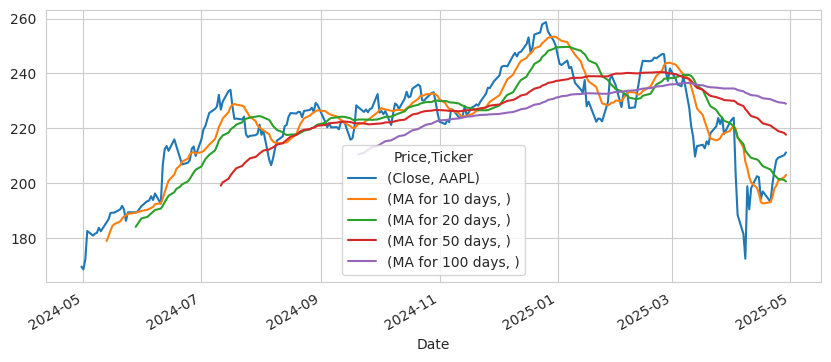

In [ ]:
AAPL[['Close','MA for 10 days','MA for 20 days','MA for 50 days','MA for 100 days']].plot(subplots=False,figsize=(10,4))

#### Section 2 - Daily Return Analysis


Now, that we've done some baseline analysis, let's go ahead and dive a little deeper. We're now going to analyze the risk of the stock.


In order to do so, we need to take a closer look at the daily changes of the stock, and not just its absolute value. Let's go ahead and use pandas to retrieve the daily returns for the APPL stock.


<Axes: xlabel='Date'>

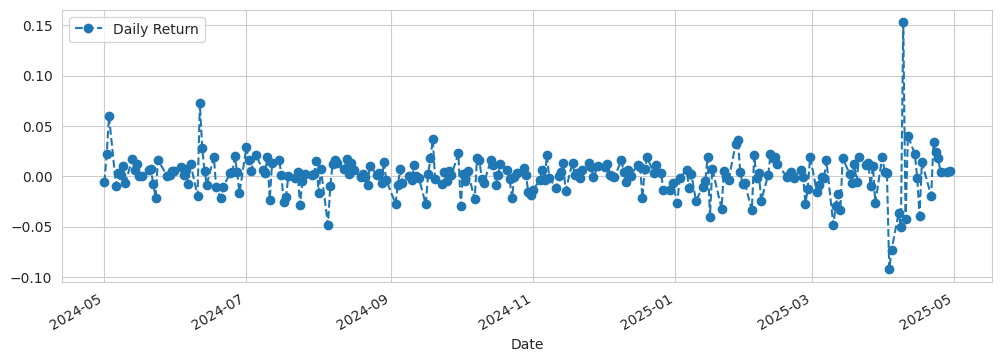

In [ ]:
AAPL['Daily Return'] = AAPL['Close'].pct_change()
AAPL['Daily Return'].plot(figsize=(12,4), legend=True, linestyle='--', marker='o')

Great, now let's get an overall look at the average daily return using a histogram. By using seaborn to create both a histogram and kde plot on the same figure.

<Axes: >

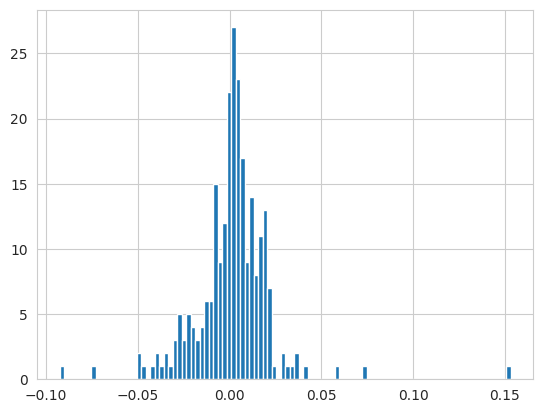

In [ ]:
AAPL['Daily Return'].hist(bins=100)

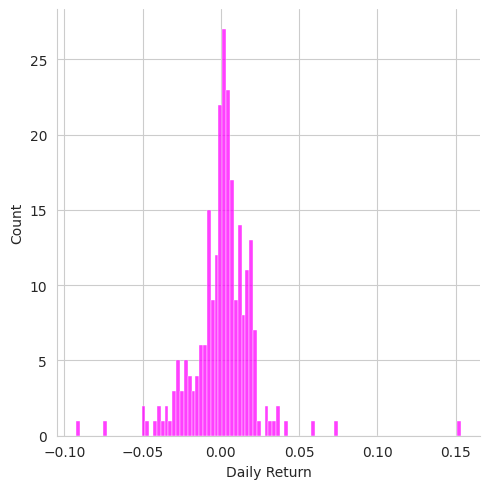

In [ ]:
sns.displot(AAPL['Daily Return'].dropna(), bins=100, color='magenta')

Now what if we wanted to analyze the returns of all the stocks in our list? For that, we need to build a DataFrame with all the ['Close'] columns for each of the stocks dataframes.

In [ ]:
closingprice_df = pd.DataFrame()

for stock in tech_list:
    try:
        data = yf.download(stock, start=start, end=end)
        closingprice_df[stock] = data['Close']
    except Exception as e:
        print(f"Failed to fetch data for {stock}: {e}")


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
closingprice_df.head(10)

,AAPL,GOOGL,MSFT,AMZN
Date,,,,
2024-04-30,169.529510,162.005463,386.380127,175.000000
2024-05-01,168.504349,163.080322,391.947632,179.000000
2024-05-02,172.216827,165.827179,394.825653,184.720001
2024-05-03,182.518173,166.444244,403.578827,186.210007
2024-05-06,180.856049,167.300171,410.406708,188.699997
2024-05-07,181.542786,170.435150,406.238525,188.759995
2024-05-08,181.881180,168.574066,407.429443,188.000000
2024-05-09,183.702606,169.151306,409.195923,189.500000
2024-05-10,182.436844,167.847519,411.597595,187.479996


Now that we have all the closing prices, let's go ahead and get the daily return for all the stocks, like we did for the APPL stock.

In [ ]:
tech_returns = closingprice_df.pct_change()

In [ ]:
tech_returns.head()

,AAPL,GOOGL,MSFT,AMZN
Date,,,,
2024-04-30,NaN,NaN,NaN,NaN
2024-05-01,-0.006047,0.006635,0.014409,0.022857
2024-05-02,0.022032,0.016844,0.007343,0.031955
2024-05-03,0.059816,0.003721,0.022170,0.008066
2024-05-06,-0.009107,0.005142,0.016918,0.013372


Now we can compare the daily percentage return of two stocks to check how correlated. First let's see a stock compared to itself.

##### GOOGL is a Alphabet Inc Class A Stock.

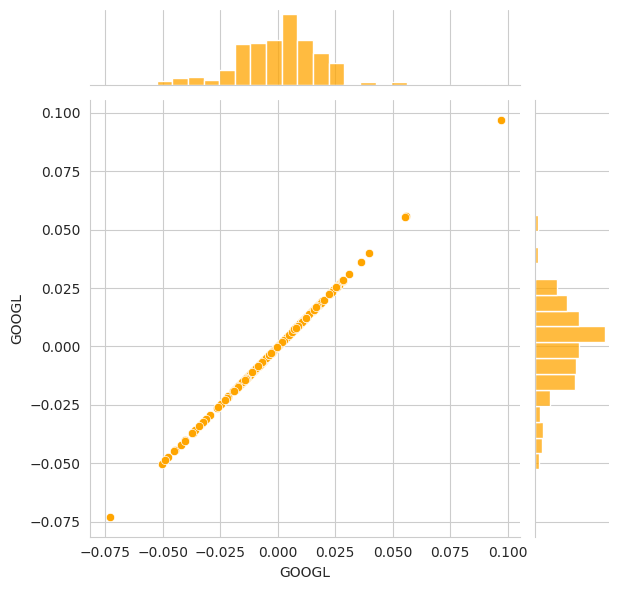

In [ ]:
import seaborn as sns
sns.jointplot(x='GOOGL', y='GOOGL', data=tech_returns, kind='scatter', color='orange')

So now we can see that if two stocks are perfectly (and positivley) correlated with each other a linear relationship bewteen its daily return values should occur.

So let's go ahead and compare Google and Amazon the same way.

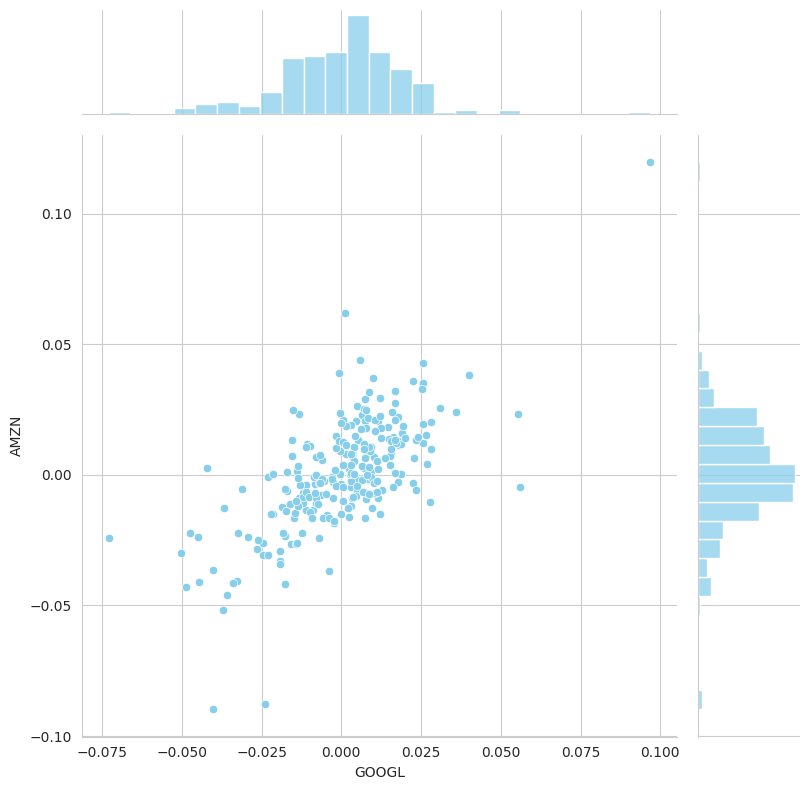

In [ ]:
import seaborn as sns
sns.jointplot(x='GOOGL', y='AMZN', data=tech_returns, kind='scatter', height=8, color='skyblue')

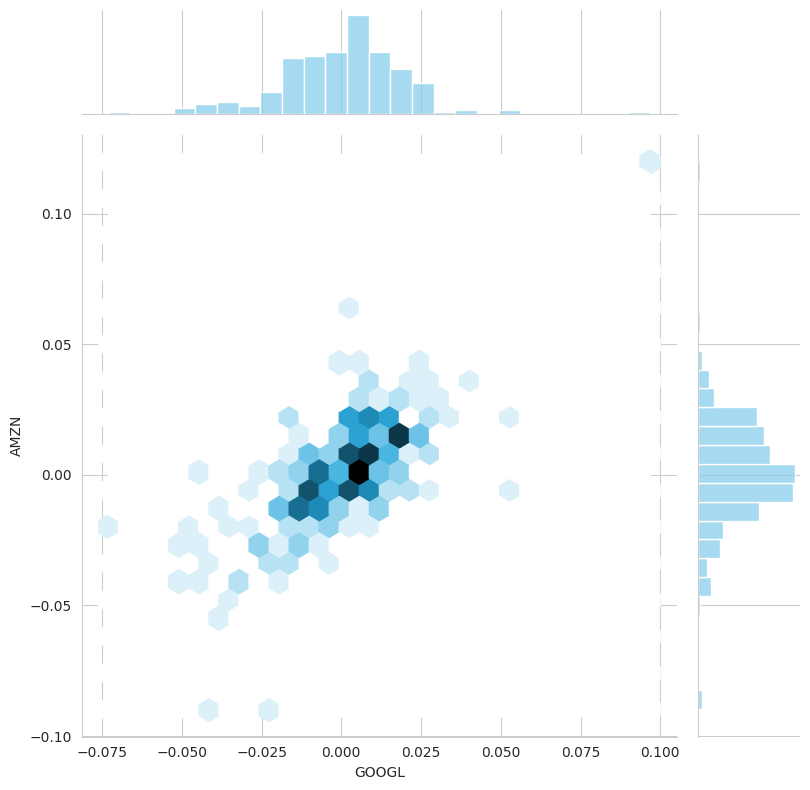

In [ ]:
import seaborn as sns
sns.jointplot(x='GOOGL', y='AMZN', data=tech_returns, kind='hex', height=8, color='skyblue')

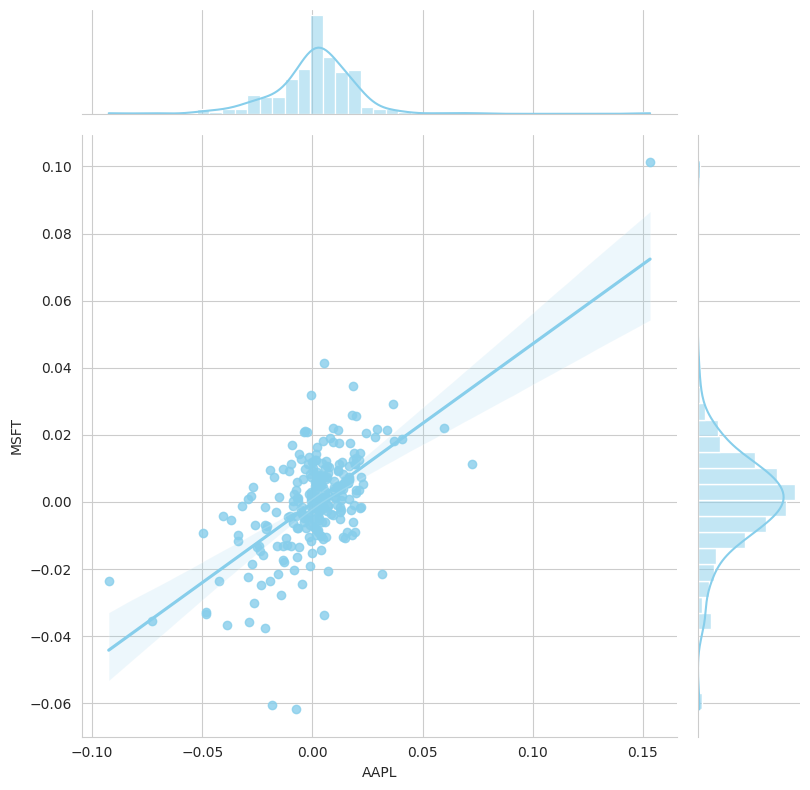

In [ ]:
import seaborn as sns
sns.jointplot(x='AAPL', y='MSFT', data=tech_returns, kind='reg', height=8, color='skyblue')

Intersting, the pearsonr value (officially known as the Pearson product-moment correlation coefficient) can give you a sense of how correlated the daily percentage returns are. You can find more information about it at this link:

Url - http://en.wikipedia.org/wiki/Pearson_product-moment_correlation_coefficient

But for a quick intuitive sense, check out the picture below.

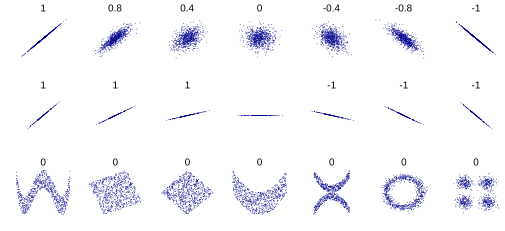

In [ ]:
from IPython.display import SVG
SVG(url='http://upload.wikimedia.org/wikipedia/commons/d/d4/Correlation_examples2.svg')

Seaborn and Pandas make it very easy to repeat this comparison analysis for every possible combination of stocks in our technology stock ticker list. We can use sns.pairplot() to automatically create this plot

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


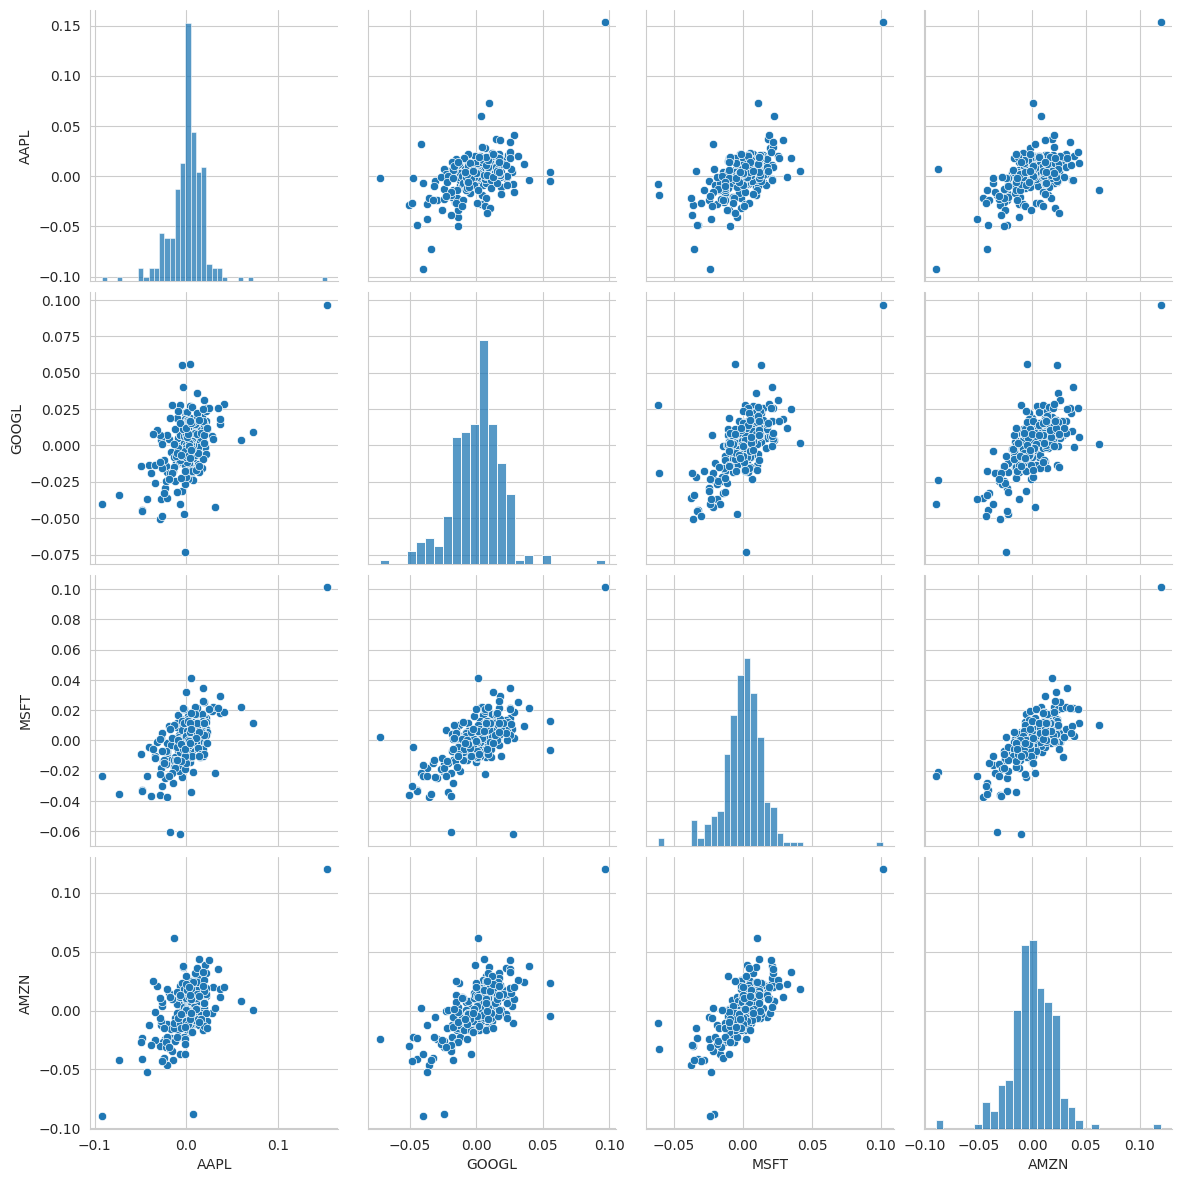

In [ ]:
sns.pairplot(tech_returns.dropna(),size=3)

Above we can see all the relationships on daily returns between all the stocks. A quick glance shows an interesting correlation between Google and Amazon daily returns. It might be interesting to investigate that individual comaprison. While the simplicity of just calling sns.pairplot() is fantastic we can also use sns.PairGrid() for full control of the figure, including what kind of plots go in the diagonal, the upper triangle, and the lower triangle.

Below is an example of utilizing the full power of seaborn to achieve this result.

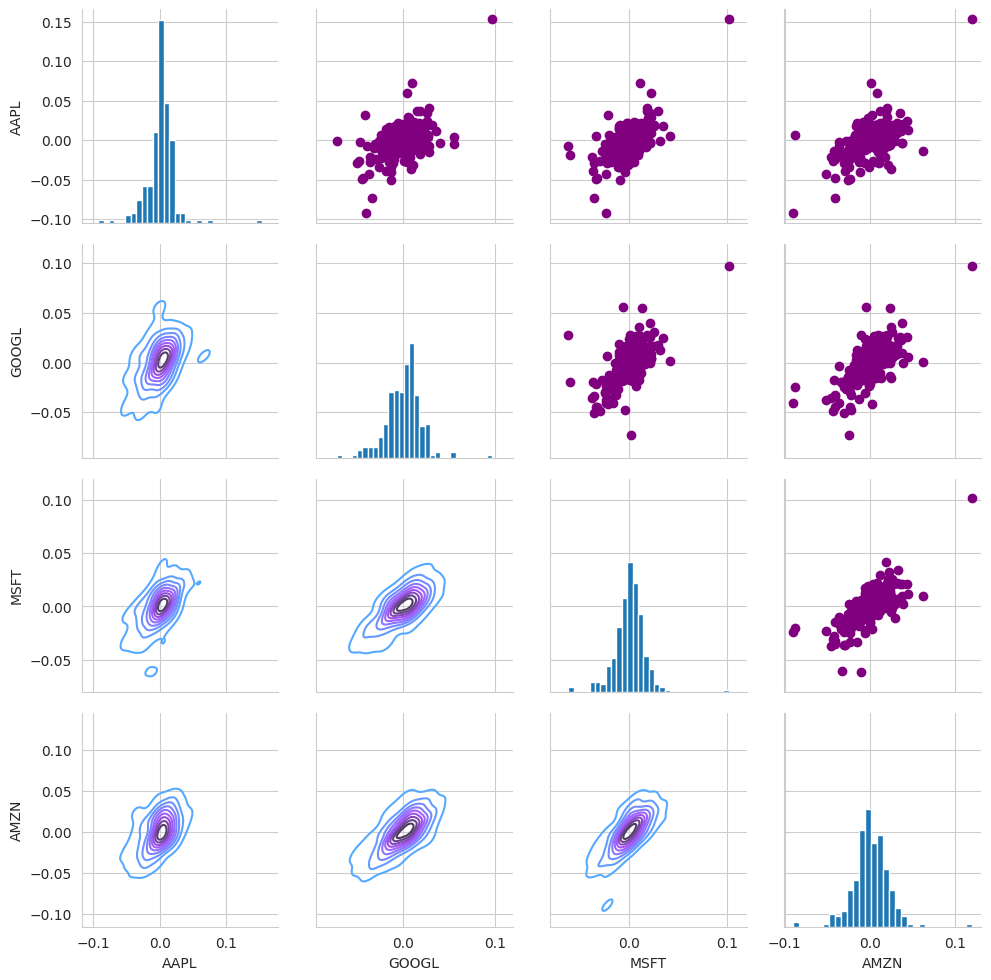

In [ ]:
returns_fig = sns.PairGrid(tech_returns.dropna())

returns_fig.map_upper(plt.scatter,color='purple')

returns_fig.map_lower(sns.kdeplot,cmap='cool_d')

returns_fig.map_diag(plt.hist,bins=30)

We can also analyze the correlation of the closing prices using this exact same technique. Here it is shown, the code repeated from above with the exception of the DataFrame called.

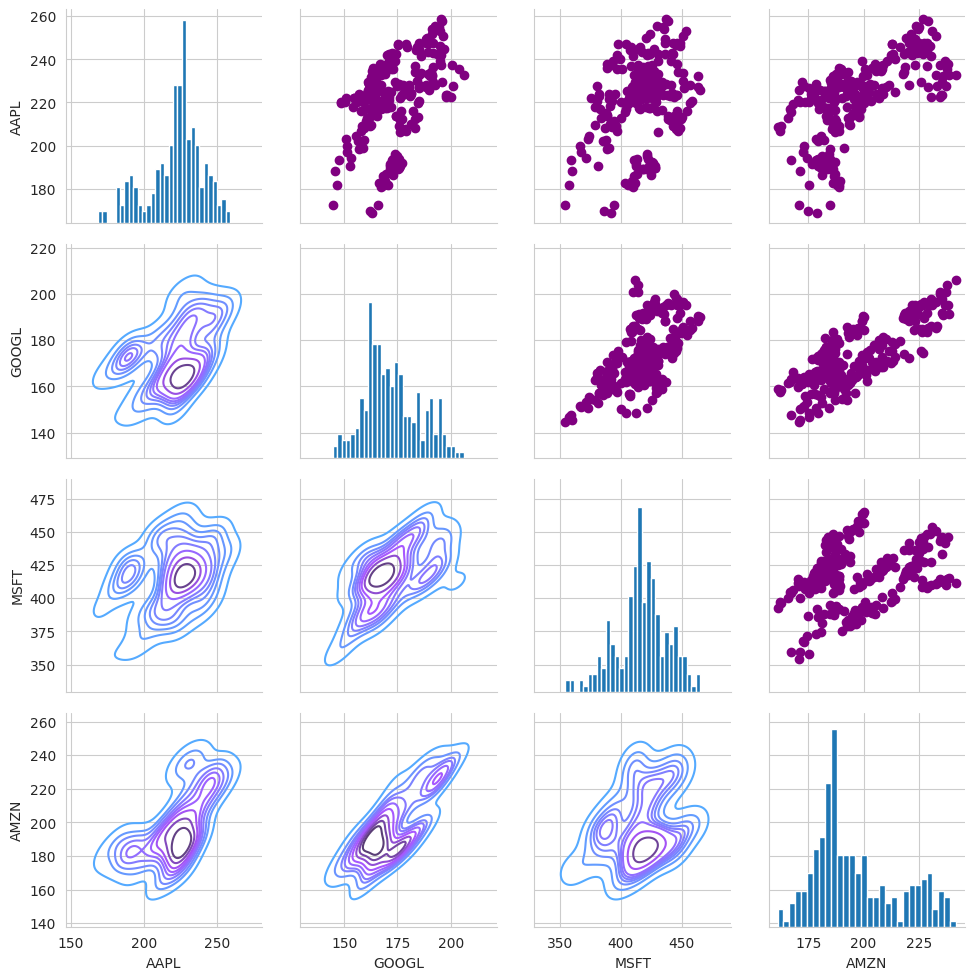

In [ ]:
returns_fig = sns.PairGrid(closingprice_df.dropna())
returns_fig.map_upper(plt.scatter,color='purple')
returns_fig.map_lower(sns.kdeplot,cmap='cool_d')
returns_fig.map_diag(plt.hist,bins=30)

Finally, we can also do a correlation plot, to get actual numerical values for the correlation between the stocks' daily return values. By comparing the closing prices, we see an interesting relationship between Google and Amazon stocks.

<Axes: >

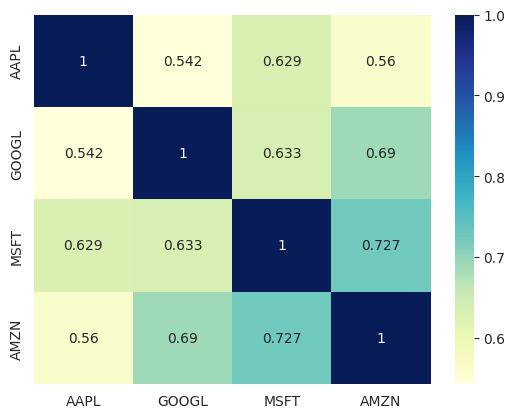

In [ ]:
sns.heatmap(tech_returns.corr(),annot=True,fmt=".3g",cmap='YlGnBu')

<Axes: >

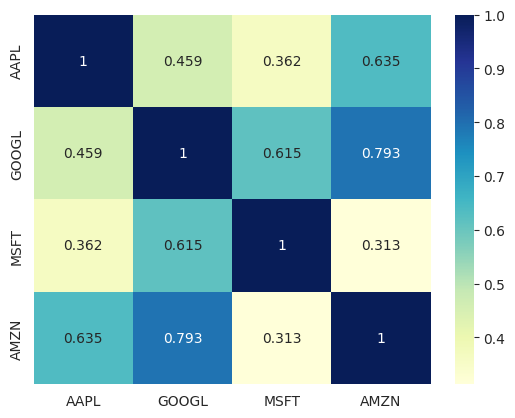

In [ ]:
sns.heatmap(closingprice_df.corr(),annot=True,fmt=".3g",cmap='YlGnBu')

##### Fantastic! Just like we suspected in our PairPlot we see here numerically and visually that Amazon and Google had the strongest correlation of daily stock return. It's also interesting to see that all the technology comapnies are positively correlated.

Great! Now that we've done some daily return analysis, let's go ahead and start looking deeper into actual risk analysis.

### Risk Analysis

There are many ways we can quantify risk, one of the most basic ways using the information we've gathered on daily percentage returns is by comparing the expected return with the standard deviation of the daily returns(Risk).

In [ ]:
rets = tech_returns.dropna()

In [ ]:
rets.head()

,AAPL,GOOGL,MSFT,AMZN
Date,,,,
2024-05-01,-0.006047,0.006635,0.014409,0.022857
2024-05-02,0.022032,0.016844,0.007343,0.031955
2024-05-03,0.059816,0.003721,0.022170,0.008066
2024-05-06,-0.009107,0.005142,0.016918,0.013372
2024-05-07,0.003797,0.018739,-0.010156,0.000318


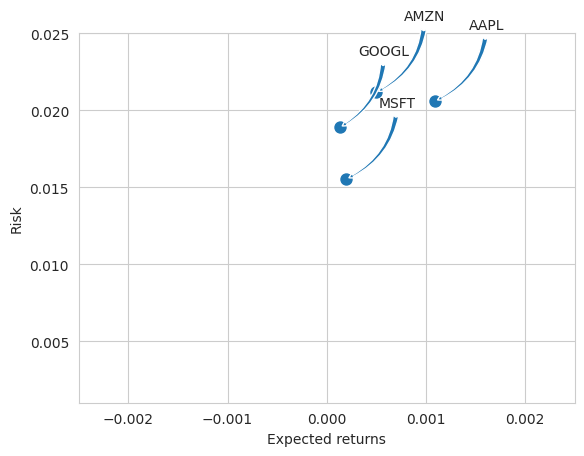

In [ ]:
area = np.pi*20

plt.scatter(rets.mean(),rets.std(),s=area)

plt.xlim([-0.0025,0.0025])
plt.ylim([0.001,0.025])

plt.xlabel('Expected returns')
plt.ylabel('Risk')

for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.annotate(
        label,
        xy = (x, y), xytext = (50, 50),
        textcoords = 'offset points', ha = 'right', va = 'bottom',
        arrowprops = dict(arrowstyle = 'fancy', connectionstyle = 'arc3,rad=-0.3'))

By looking at the scatter plot we can say these stocks have lower risk and positive expected returns.

### Value at Risk

Let's go ahead and define a value at risk parameter for our stocks. We can treat value at risk as the amount of money we could expect to lose (aka putting at risk) for a given confidence interval. There's several methods we can use for estimating a value at risk. Let's go ahead and see some of them in action.

#### Value at risk using the "bootstrap" method
For this method we will calculate the empirical quantiles from a histogram of daily returns. For more information on quantiles, check out this link: http://en.wikipedia.org/wiki/Quantile

Let's go ahead and repeat the daily returns histogram for Apple stock.

<ipython-input-113-ca28547d8edc>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(AAPL['Daily Return'].dropna(),bins=100,color='purple')


<Axes: xlabel='Daily Return', ylabel='Density'>

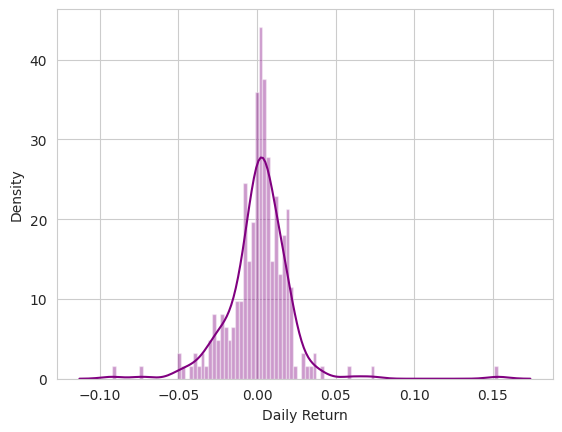

In [ ]:
sns.distplot(AAPL['Daily Return'].dropna(),bins=100,color='purple')

Now we can use quantile to get the risk value for the stock.

In [ ]:
rets["AAPL"].quantile(0.05)

np.float64(-0.029170272516156316)

The 0.05 empirical quantile of daily returns is at -0.016. That means that with 95% confidence, our worst daily loss will not exceed 1.6%. If we have a 1 million dollar investment, our one-day 5% VaR is 0.016 * 1,000,000 = $16,000.

In [ ]:
rets["AMZN"].quantile(0.05)

np.float64(-0.031965164875257024)

In [ ]:
rets["GOOGL"].quantile(0.05)

np.float64(-0.03345105794316996)

In [ ]:
rets["MSFT"].quantile(0.05)

np.float64(-0.024140759904102516)

#### Value at Risk using the Monte Carlo method
Using the Monte Carlo to run many trials with random market conditions, then we'll calculate portfolio losses for each trial. After this, we'll use the aggregation of all these simulations to establish how risky the stock is.

Let's start with a brief explanation of what we're going to do:

We will use the geometric Brownian motion (GBM), which is technically known as a Markov process. This means that the stock price follows a random walk and is consistent with (at the very least) the weak form of the efficient market hypothesis (EMH): past price information is already incorporated and the next price movement is "conditionally independent" of past price movements.

This means that the past information on the price of a stock is independent of where the stock price will be in the future, basically meaning, you can't perfectly predict the future solely based on the previous price of a stock.


Now we see that the change in the stock price is the current stock price multiplied by two terms. The first term is known as "drift", which is the average daily return multiplied by the change of time. The second term is known as "shock", for each time period the stock will "drift" and then experience a "shock" which will randomly push the stock price up or down. By simulating this series of steps of drift and shock thousands of times, we can begin to do a simulation of where we might expect the stock price to be.

For more info on the Monte Carlo method for stocks and simulating stock prices with GBM model ie. geometric Brownian motion (GBM).

check out the following link: http://www.investopedia.com/articles/07/montecarlo.asp

To demonstrate a basic Monte Carlo method, we will start with just a few simulations. First we'll define the variables we'll be using in the Google stock DataFrame GOOGL


In [ ]:
rets.head()

,AAPL,GOOGL,MSFT,AMZN
Date,,,,
2024-05-01,-0.006047,0.006635,0.014409,0.022857
2024-05-02,0.022032,0.016844,0.007343,0.031955
2024-05-03,0.059816,0.003721,0.022170,0.008066
2024-05-06,-0.009107,0.005142,0.016918,0.013372
2024-05-07,0.003797,0.018739,-0.010156,0.000318


In [ ]:
days = 365
dt = 1/days
mu = rets.mean()['GOOGL']
sigma = rets.std()['GOOGL']

Next, we will create a function that takes in the starting price and number of days, and uses the sigma and mu we already calculated form our daily returns.

In [ ]:
def stock_monte_carlo(start_price,days,mu,sigma):
    ''' This function takes in starting stock price, days of simulation,mu,sigma, and returns simulated price array'''

    price = np.zeros(days)
    price[0] = start_price

    shock = np.zeros(days)
    drift = np.zeros(days)

    for x in range(1,days):

        shock[x] = np.random.normal(loc=mu * dt, scale=sigma * np.sqrt(dt))
        drift[x] = mu * dt
        price[x] = price[x-1] + (price[x-1] * (drift[x] + shock[x]))

    return price

Awesome! Now lets put above function to work.

In [ ]:
print(closingprice_df['GOOGL'].head())

Date
2024-04-30    162.005463
2024-05-01    163.080322
2024-05-02    165.827179
2024-05-03    166.444244
2024-05-06    167.300171
Name: GOOGL, dtype: float64


Text(0.5, 1.0, 'Monte Carlo Analysis for Google')

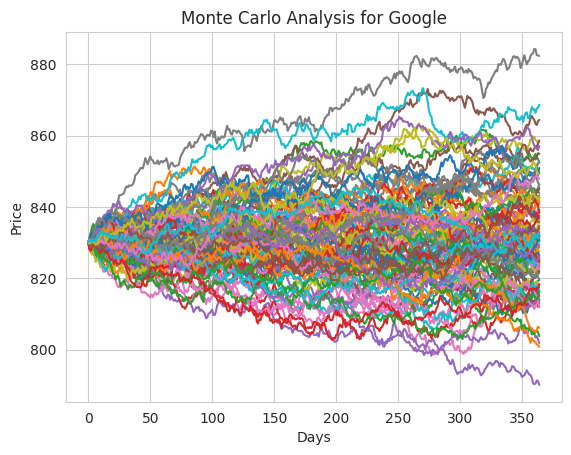

In [ ]:
start_price = 830.09

for run in range(100):
    plt.plot(stock_monte_carlo(start_price, days, mu, sigma))

plt.xlabel("Days")
plt.ylabel("Price")
plt.title('Monte Carlo Analysis for Google')

In [ ]:
print(closingprice_df['AMZN'].head())

Date
2024-04-30    175.000000
2024-05-01    179.000000
2024-05-02    184.720001
2024-05-03    186.210007
2024-05-06    188.699997
Name: AMZN, dtype: float64


Text(0.5, 1.0, 'Monte Carlo Analysis for Amazon')

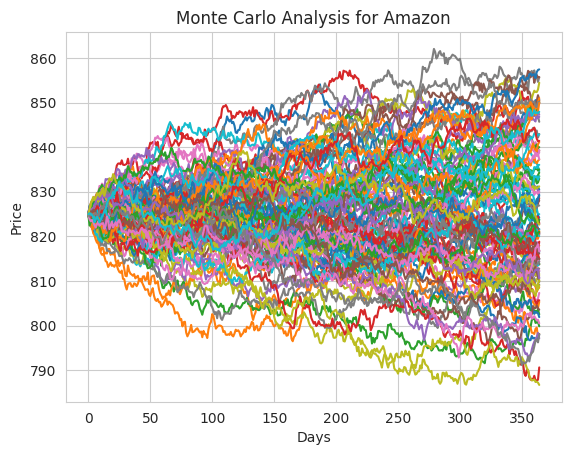

In [ ]:
start_price = 824.95

for run in range(100):
    plt.plot(stock_monte_carlo(start_price, days, mu, sigma))

plt.xlabel("Days")
plt.ylabel("Price")
plt.title('Monte Carlo Analysis for Amazon')

In [ ]:
AAPL.head()

Price,Close,High,Low,Open,Volume,MA for 10 days,MA for 20 days,MA for 50 days,MA for 100 days,Daily Return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
Date,,,,,,,,,,
2024-04-30,169.529510,174.167614,169.201060,172.515412,65934800,NaN,NaN,NaN,NaN,NaN
2024-05-01,168.504349,171.898327,168.315239,168.783032,50383100,NaN,NaN,NaN,NaN,-0.006047
2024-05-02,172.216827,172.604994,170.086885,171.699267,94214900,NaN,NaN,NaN,NaN,0.022032
2024-05-03,182.518173,186.121155,181.801556,185.772794,163224100,NaN,NaN,NaN,NaN,0.059816
2024-05-06,180.856049,183.334337,179.572103,181.493040,78569700,NaN,NaN,NaN,NaN,-0.009107


Text(0.5, 1.0, 'Monte Carlo Analysis for Apple')

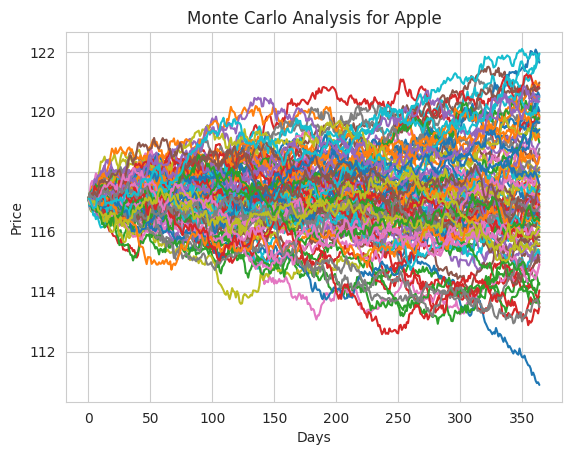

In [ ]:
start_price = 117.10

for run in range(100):
    plt.plot(stock_monte_carlo(start_price, days, mu, sigma))

plt.xlabel("Days")
plt.ylabel("Price")
plt.title('Monte Carlo Analysis for Apple')

In [ ]:
print(closingprice_df['MSFT'].head())


Date
2024-04-30    386.380127
2024-05-01    391.947632
2024-05-02    394.825653
2024-05-03    403.578827
2024-05-06    410.406708
Name: MSFT, dtype: float64


Text(0.5, 1.0, 'Monte Carlo Analysis for Microsoft')

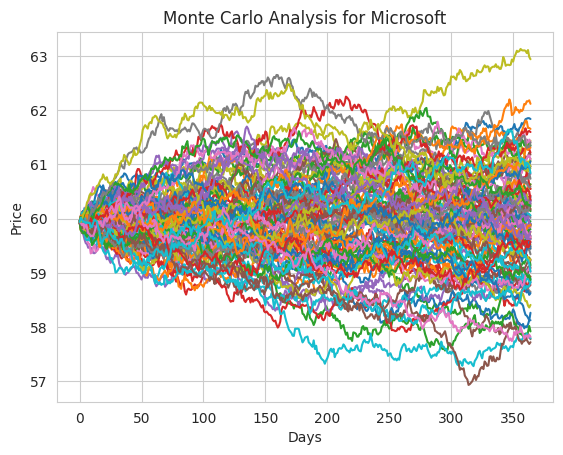

In [ ]:
start_price = 59.94

for run in range(100):
    plt.plot(stock_monte_carlo(start_price, days, mu, sigma))

plt.xlabel("Days")
plt.ylabel("Price")
plt.title('Monte Carlo Analysis for Microsoft')

Let's go ahead and get a histogram of the end results for a much larger run. (note: This could take a little while to run , depending on the number of runs chosen)

In [ ]:
start_price = 830.09

runs = 10000

simulations = np.zeros(runs)

for run in range(runs):
    simulations[run] = stock_monte_carlo(start_price,days,mu,sigma)[days-1]

Now that we have our array of simulations, we can go ahead and plot a histogram ,as well as use qunatile to define our risk for this stock.

For more info on quantiles, check out this link: http://en.wikipedia.org/wiki/Quantile

Text(0.5, 1.0, 'Final price distribution for Google Stock(GOOGL) after 365 days')

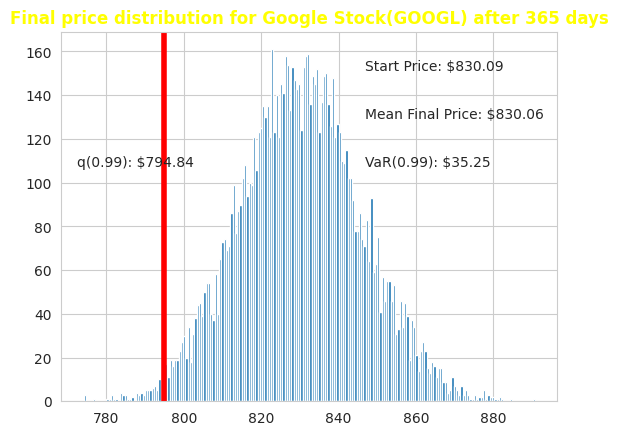

In [ ]:
q = np.percentile(simulations, 1)

plt.hist(simulations, bins=200)

plt.figtext(0.6, 0.8, s='Start Price: $%.2f' % start_price)

plt.figtext(0.6, 0.7, s='Mean Final Price: $%.2f' % simulations.mean())

plt.figtext(0.6, 0.6, s='VaR(0.99): $%.2f' % (start_price - q))

plt.figtext(0.15, 0.6, s="q(0.99): $%.2f" % q)

plt.axvline(x=q, linewidth=4, color='r')

plt.title("Final price distribution for Google Stock(GOOGL) after %s days" % days, weight='bold', color='yellow')


Awesome! Now we have looked at the 1% empirical quantile of the final price distribution to estimate the Value at Risk for the Google Stock(GOOGL), which looks to be $17.98 for every investment of
830.09 (The price of one initial Google Stock).

This basically means for every initial GOOGL stock you purchase you're putting about $17.98 at risk 99% of the time from our Monte Carlo Simulation.


##### Now lets plot remaining Stocks to estimate the VaR with our Monte Carlo Simulation.

In [ ]:
start_price = 824.95

runs = 10000

simulations = np.zeros(runs)

for run in range(runs):
    simulations[run] = stock_monte_carlo(start_price,days,mu,sigma)[days-1]

Text(0.5, 1.0, 'Final price distribution for Amazon Stock(AMZN) after 365 days')

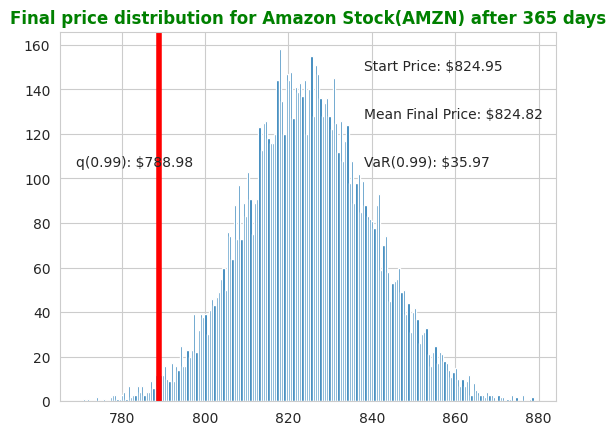

In [ ]:
q = np.percentile(simulations, 1)

plt.hist(simulations, bins=200)

plt.figtext(0.6, 0.8, s='Start Price: $%.2f' % start_price)

plt.figtext(0.6, 0.7, s='Mean Final Price: $%.2f' % simulations.mean())

plt.figtext(0.6, 0.6, s='VaR(0.99): $%.2f' % (start_price - q))

plt.figtext(0.15, 0.6, s="q(0.99): $%.2f" % q)

plt.axvline(x=q, linewidth=4, color='r')

plt.title("Final price distribution for Amazon Stock(AMZN) after %s days" % days, weight='bold', color='green')

This basically means for every initial AMZN stock you purchase you're putting about $18.13 at risk 99% of the time from our Monte Carlo Simulation.

In [ ]:
start_price = 117.10

runs = 10000

simulations = np.zeros(runs)

for run in range(runs):
    simulations[run] = stock_monte_carlo(start_price,days,mu,sigma)[days-1]

Text(0.5, 1.0, 'Final price distribution for Apple Stock(AAPL) after 365 days')

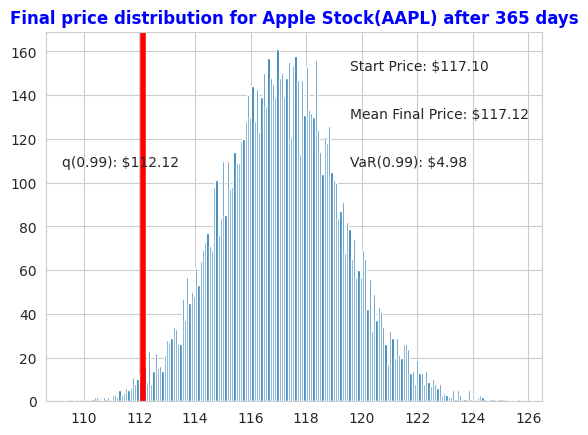

In [ ]:
q = np.percentile(simulations, 1)

plt.hist(simulations, bins=200)

plt.figtext(0.6, 0.8, s='Start Price: $%.2f' % start_price)

plt.figtext(0.6, 0.7, s='Mean Final Price: $%.2f' % simulations.mean())

plt.figtext(0.6, 0.6, s='VaR(0.99): $%.2f' % (start_price - q))

plt.figtext(0.15, 0.6, s="q(0.99): $%.2f" % q)

plt.axvline(x=q, linewidth=4, color='r')

plt.title("Final price distribution for Apple Stock(AAPL) after %s days" % days, weight='bold', color='blue')

Great! This basically means for every initial AAPL stock you purchase you're putting about $2.48 at risk 99% of the time from our Monte Carlo Simulation.

In [ ]:
start_price = 59.94

runs = 10000

simulations = np.zeros(runs)

for run in range(runs):
    simulations[run] = stock_monte_carlo(start_price,days,mu,sigma)[days-1]

Text(0.5, 1.0, 'Final price distribution for Microsoft Stock(MSFT) after 365 days')

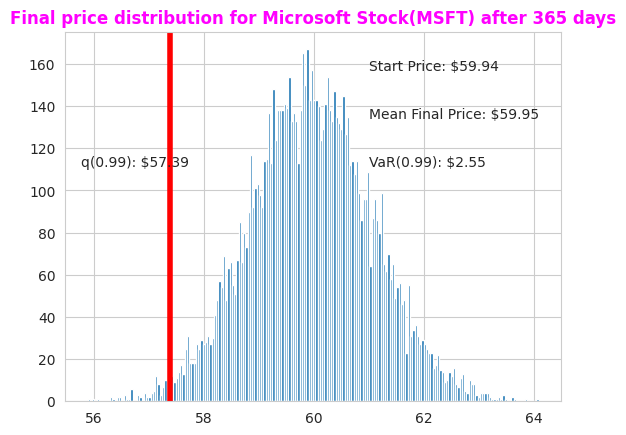

In [ ]:
q = np.percentile(simulations, 1)

plt.hist(simulations, bins=200)

plt.figtext(0.6, 0.8, s='Start Price: $%.2f' % start_price)

plt.figtext(0.6, 0.7, s='Mean Final Price: $%.2f' % simulations.mean())

plt.figtext(0.6, 0.6, s='VaR(0.99): $%.2f' % (start_price - q))

plt.figtext(0.15, 0.6, s="q(0.99): $%.2f" % q)

plt.axvline(x=q, linewidth=4, color='r')

plt.title("Final price distribution for Microsoft Stock(MSFT) after %s days" % days, weight='bold', color='magenta')

Nice, This basically means for every initial MSFT stock you purchase you're putting about $1.28 at risk 99% of the time from our Monte Carlo Simulation.

Now lets estiamte the Value at Risk(VaR) for a stock related to other domains.


We'll estimate the VaR for:
 - Johnson & Johnson > JNJ (U.S.: NYSE) [JNJ](http://quotes.wsj.com/JNJ)
 - Wal-Mart Stores Inc. > WMT (U.S.: NYSE) [WMT](http://quotes.wsj.com/WMT)
 - Nike Inc. > NKE (U.S.: NYSE) [NKE](http://quotes.wsj.com/NKE)


By using the above methods to get Value at Risk.

In [ ]:
import yfinance as yf
from datetime import datetime, timedelta

NYSE_list = ['JNJ', 'NKE', 'WMT']

end = datetime.now()
start = end - timedelta(days=365)

stock_data = {}

for stock in NYSE_list:
    try:
        stock_data[stock] = yf.download(stock, start=start, end=end)
    except Exception as e:
        print(f"Failed to fetch data for {stock}: {e}")

if 'JNJ' in stock_data:
    JNJ = stock_data['JNJ']
else:
    print("JNJ data is not available.")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Let's go ahead and play aorund with the JNJ(Johnson & Johnson) Stock DataFrame to get a feel for the data.

In [ ]:
JNJ.head()

Price,Close,High,Low,Open,Volume
Ticker,JNJ,JNJ,JNJ,JNJ,JNJ
Date,,,,,
2024-04-30,140.095627,142.314454,140.037494,142.314454,8817700
2024-05-01,146.480774,147.129961,143.031434,144.116630,14470900
2024-05-02,145.259933,147.595025,144.504180,147.314031,8459800
2024-05-03,144.630142,145.230866,143.225217,145.230866,6532700
2024-05-06,143.961594,145.385902,143.312421,145.211489,5042800


In [ ]:
JNJ.describe()

Price,Close,High,Low,Open,Volume
Ticker,JNJ,JNJ,JNJ,JNJ,JNJ
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02
mean,153.118935,154.244284,151.838439,153.015663,7.917344e+06
std,7.485073,7.538001,7.461549,7.509144,3.024408e+06
min,140.095627,142.038768,139.562839,139.880305,3.164100e+06
25%,145.653069,146.740700,144.516295,145.584647,5.835075e+06
50%,153.516159,154.650780,152.453277,153.580362,7.256450e+06
75%,159.040619,160.587909,158.034777,159.122774,8.959750e+06
max,167.699997,169.990005,167.050003,168.080002,2.330310e+07


In [ ]:
JNJ.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2024-04-30 to 2025-04-29
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, JNJ)   250 non-null    float64
 1   (High, JNJ)    250 non-null    float64
 2   (Low, JNJ)     250 non-null    float64
 3   (Open, JNJ)    250 non-null    float64
 4   (Volume, JNJ)  250 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.7 KB


Now that we've seen the DataFrame, let's go ahead and plot out the closing prices of NYSE stocks.

<Axes: title={'center': 'Closing Price - JNJ'}, xlabel='Date'>

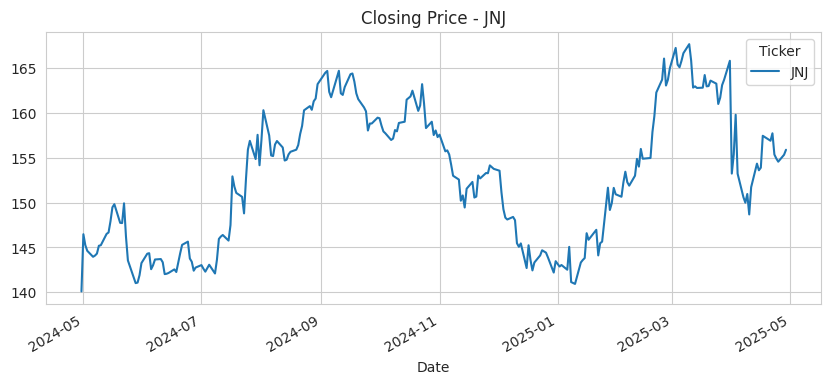

In [ ]:
JNJ['Close'].plot(title='Closing Price - JNJ',legend=True, figsize=(10,4))

<Axes: title={'center': 'Closing Price - NKE'}, xlabel='Date'>

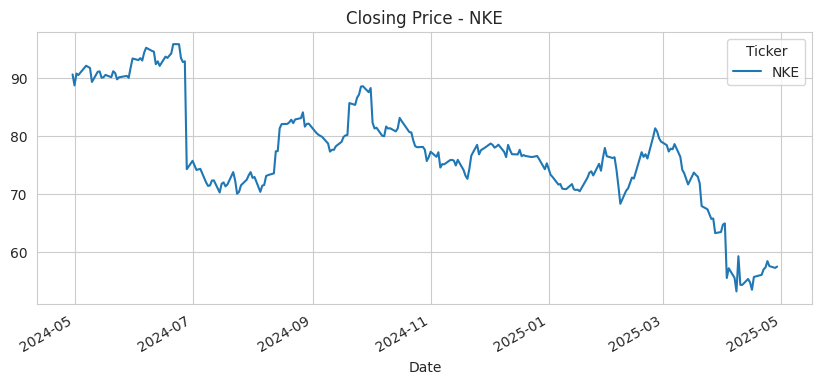

In [ ]:
if 'NKE' in stock_data:
    NKE = stock_data['NKE']
else:
    print("NKE data is not available.")

NKE['Close'].plot(title='Closing Price - NKE', legend=True, figsize=(10, 4))

<Axes: title={'center': 'Closing Price - WMT'}, xlabel='Date'>

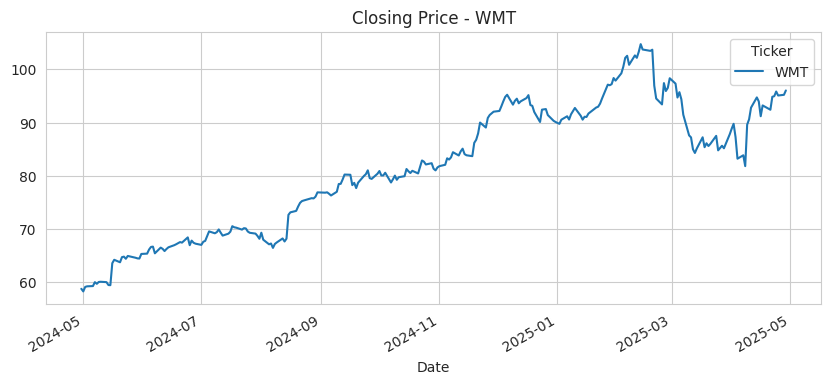

In [ ]:
if 'WMT' in stock_data:
    WMT = stock_data['WMT']
else:
    print("WMT data is not available.")

WMT['Close'].plot(title='Closing Price - WMT', legend=True, figsize=(10, 4))

### Value at risk using the "Bootstrap" method

we will calculate the empirical quantiles from a histogram of daily returns.

Let's go ahead and use pandas to retrieve the daily returns for the JNJ, WMT & NKE stock.

In [ ]:
JNJ['Daily Return'] = JNJ['Close'].pct_change()

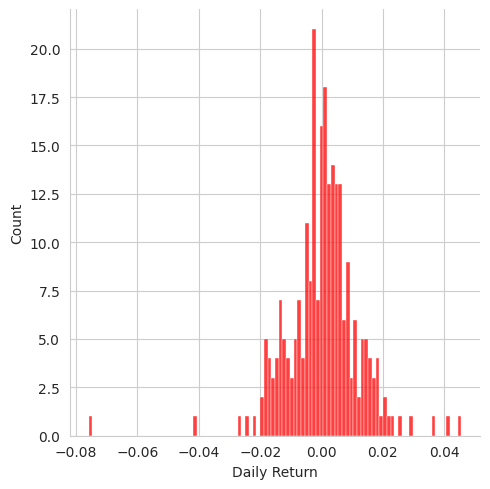

In [ ]:
sns.displot(JNJ['Daily Return'].dropna(), bins=100, color='r')

In [ ]:
(JNJ['Daily Return'].dropna()).quantile(0.05)

np.float64(-0.01725240732010056)

The 0.05 empirical quantile of JNJ stock daily returns is at -0.010. That means that with 95% confidence, our worst daily loss will not exceed 1%. If we have a 1 million dollar investment, our one-day 5% VaR is 0.010 * 1,000,000 = $10,000.

In [ ]:
WMT['Daily Return'] = WMT['Close'].pct_change()

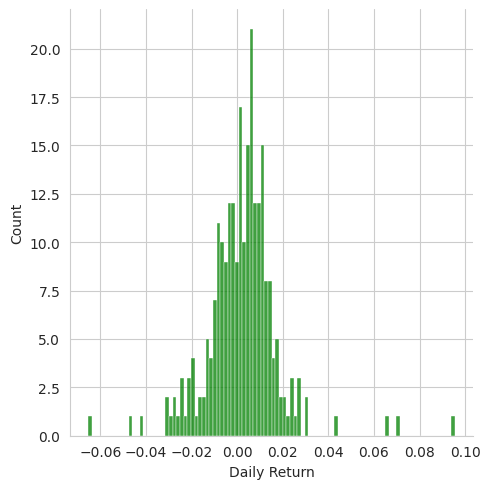

In [ ]:
sns.displot(WMT['Daily Return'].dropna(), bins=100, color='g')

In [ ]:
(WMT['Daily Return'].dropna()).quantile(0.05)

np.float64(-0.02223193359980551)

The 0.05 empirical quantile of WMT stock daily returns is at -0.013. That means that with 95% confidence, our worst daily loss will not exceed 1.3%. If we have a 1 million dollar investment, our one-day 5% VaR is 0.013 * 1,000,000 = $13,000.

In [ ]:
NKE['Daily Return'] = NKE['Close'].pct_change()

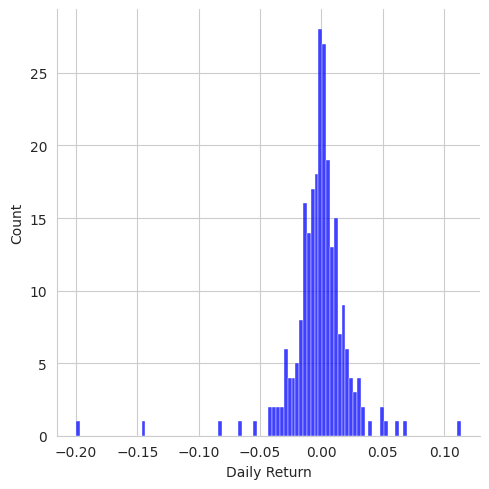

In [ ]:
sns.displot(NKE['Daily Return'].dropna(), bins=100, color='b')

In [ ]:
(NKE['Daily Return'].dropna()).quantile(0.05)

np.float64(-0.030607556969242843)

The 0.05 empirical quantile of NKE stock daily returns is at -0.018. That means that with 95% confidence, our worst daily loss will not exceed 1.8%. If we have a 1 million dollar investment, our one-day 5% VaR is 0.018 * 1,000,000 = $18,000.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
import tensorflow as tf
import os
import psutil

physical_devices = tf.config.list_physical_devices()
if not physical_devices:
    print("No devices found, using CPU.")
else:
    for device in physical_devices:
        print(f"Device: {device.device_type}, Name: {device.name}")

if tf.config.list_physical_devices('GPU'):
    print("\n✅ Using GPU")
    for gpu in tf.config.experimental.list_physical_devices('GPU'):
        details = tf.config.experimental.get_device_details(gpu)
        print(f"GPU Name: {details.get('device_name', 'Unknown')}")
else:
    print("\n✅ Using CPU")

print(f"\nCPU Cores: {os.cpu_count()}")
print(f"Physical Cores: {psutil.cpu_count(logical=False)}")
print(f"Logical Cores: {psutil.cpu_count(logical=True)}")

Device: CPU, Name: /physical_device:CPU:0
Device: GPU, Name: /physical_device:GPU:0

✅ Using GPU
GPU Name: Tesla T4

CPU Cores: 2
Physical Cores: 1
Logical Cores: 2


In [ ]:
def monte_carlo_simulation(stock_data, num_simulations=100, num_days=365):
    close_prices = stock_data['Close'].values
    log_returns = np.log(1 + stock_data['Close'].pct_change().dropna())
    mu = log_returns.mean()
    sigma = log_returns.std()
    last_price = close_prices[-1]

    simulated_prices = np.zeros((num_simulations, num_days))
    for i in range(num_simulations):
        daily_returns = np.random.normal(mu, sigma, num_days - 1)
        price_path = np.zeros(num_days)
        price_path[0] = last_price
        for j in range(1, num_days):
            price_path[j] = price_path[j - 1] * np.exp(daily_returns[j - 1])
        simulated_prices[i] = price_path
    return simulated_prices

In [ ]:
def prepare_lstm_data_from_mc(simulated_prices, lookback_window, prediction_window):
    all_X = []
    all_y = []
    for path in simulated_prices:
        data = path.reshape(-1, 1)
        for i in range(len(data) - lookback_window - prediction_window + 1):
            all_X.append(data[i : i + lookback_window])
            all_y.append(data[i + lookback_window : i + lookback_window + prediction_window])
    return np.array(all_X), np.array(all_y)

In [ ]:
def train_bi_lstm_from_mc(X_train, y_train, lookback_window, prediction_window, epochs=20, batch_size=32, validation_split=0.2):
    scaler_x = MinMaxScaler()
    X_train_scaled = scaler_x.fit_transform(X_train.reshape(-1, 1)).reshape(X_train.shape)

    scaler_y = MinMaxScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, prediction_window)).reshape(y_train.shape)

    model = Sequential([
        Bidirectional(LSTM(50, return_sequences=True, input_shape=(lookback_window, 1))),
        Dropout(0.2),
        Bidirectional(LSTM(50, return_sequences=False)),
        Dropout(0.2),
        Dense(prediction_window)
    ])

    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(X_train_scaled, y_train_scaled, epochs=epochs, batch_size=batch_size, validation_split=validation_split)

    return model, scaler_x, scaler_y

In [ ]:
def predict_future_bi_lstm_from_mc(model, last_real_prices, scaler_x, prediction_window, lookback_window):
    scaled_last_real_prices = scaler_x.transform(last_real_prices.reshape(-1, 1))
    input_sequence = scaled_last_real_prices.reshape(1, lookback_window, 1)
    predicted_scaled = model.predict(input_sequence)
    predicted_prices = scaler_x.inverse_transform(predicted_scaled.reshape(-1, 1)).flatten()
    return predicted_prices

In [ ]:
def predict_stock_price(stock_symbol):
    today = datetime.now()
    start_date = today - timedelta(days=365 * 5)

    data = yf.download(stock_symbol, start=start_date, end=today)
    if data.empty:
        print(f"Invalid stock symbol or no data available for {stock_symbol}.")
        return

    num_simulations = 200
    num_days_simulate = 365
    simulated_prices = monte_carlo_simulation(data, num_simulations, num_days_simulate)

    lookback_window = 60
    prediction_window = 180
    X_train, y_train = prepare_lstm_data_from_mc(simulated_prices, lookback_window, prediction_window)

    model, scaler_x, scaler_y = train_bi_lstm_from_mc(
        X_train, y_train, lookback_window, prediction_window, epochs=20, batch_size=128, validation_split=0.1
    )

    last_real_prices = data['Close'][-lookback_window:].values.reshape(-1, 1)

    future_predictions = predict_future_bi_lstm_from_mc(
        model, last_real_prices, scaler_x, prediction_window, lookback_window
    )

    future_dates = pd.date_range(start=today, periods=prediction_window)
    pred_df = pd.DataFrame({'Date': future_dates, 'Predicted Price': future_predictions})
    pred_df = pred_df.resample('ME', on='Date').mean()

    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data['Close'], label='Actual Prices')
    plt.plot(pred_df.index, pred_df['Predicted Price'], label='Monthly Predicted Prices', linestyle='dashed', marker='o')
    plt.xlabel('Date')
    plt.ylabel('Stock Price')
    plt.title(f'{stock_symbol} Monthly Stock Price Prediction')
    plt.legend()
    plt.grid(True)
    plt.show()

[*********************100%***********************]  1 of 1 completed
<ipython-input-154-ebf7ea2d59b7>:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  price_path[0] = last_price


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


178/178 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.0298 - val_loss: 0.0044
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0080 - val_loss: 0.0040
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 0.0076 - val_loss: 0.0041
Epoch 4/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0074 - val_loss: 0.0043
Epoch 5/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0073 - val_loss: 0.0045
Epoch 6/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0073 - val_loss: 0.0043
Epoch 7/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0073 - val_loss: 0.0041
Epoch 8/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0069 - val_loss: 0.0045
Epoch 9/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0069 - val_loss: 0.0046
Epoch 10/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0072 - val_loss: 0.0047
Epoch 11/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0069 - val_loss: 0.0039
Epoch 12/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/ste

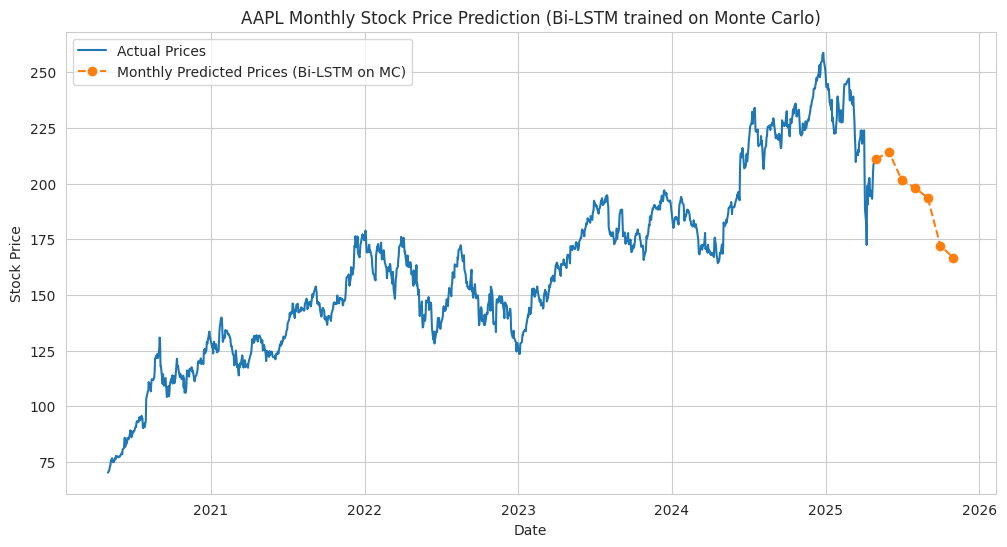

In [ ]:
predict_stock_price('AAPL')

[*********************100%***********************]  1 of 1 completed
<ipython-input-154-ebf7ea2d59b7>:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  price_path[0] = last_price
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0062 - val_loss: 0.0060
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0023 - val_loss: 0.0068
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0021 - val_loss: 0.0061
Epoch 4/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0020 - val_loss: 0.0061
Epoch 5/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0020 - val_loss: 0.0061
Epoch 6/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0020 - val_loss: 0.0063
Epoch 7/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0020 - val_loss: 0.0061
Epoch 8/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0020 - val_loss: 0.0058
Epoch 9/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0020 - val_loss: 0.0060
Epoch 10/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0020 - val_loss: 0.0065
Epoch 11/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0019 - val_loss: 0.0064
Epoch 12/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 

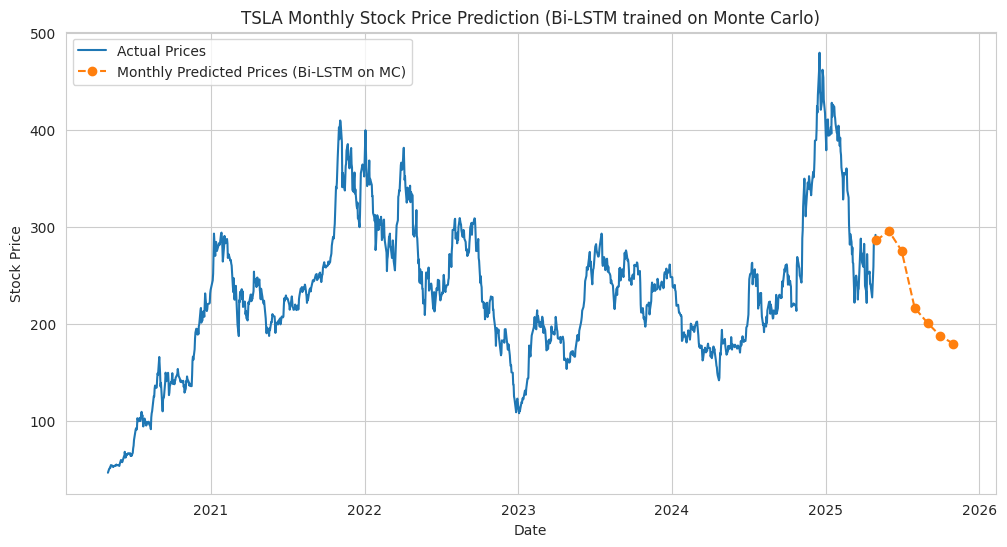

In [ ]:
predict_stock_price('TSLA')

[*********************100%***********************]  1 of 1 completed
<ipython-input-154-ebf7ea2d59b7>:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  price_path[0] = last_price
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.0181 - val_loss: 0.0051
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0053 - val_loss: 0.0049
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0049 - val_loss: 0.0048
Epoch 4/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0047 - val_loss: 0.0047
Epoch 5/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 6/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0045 - val_loss: 0.0045
Epoch 7/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 8/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0046 - val_loss: 0.0044
Epoch 9/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0044 - val_loss: 0.0045
Epoch 10/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0044 - val_loss: 0.0047
Epoch 11/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0045 - val_loss: 0.0046
Epoch 12/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 681ms/step


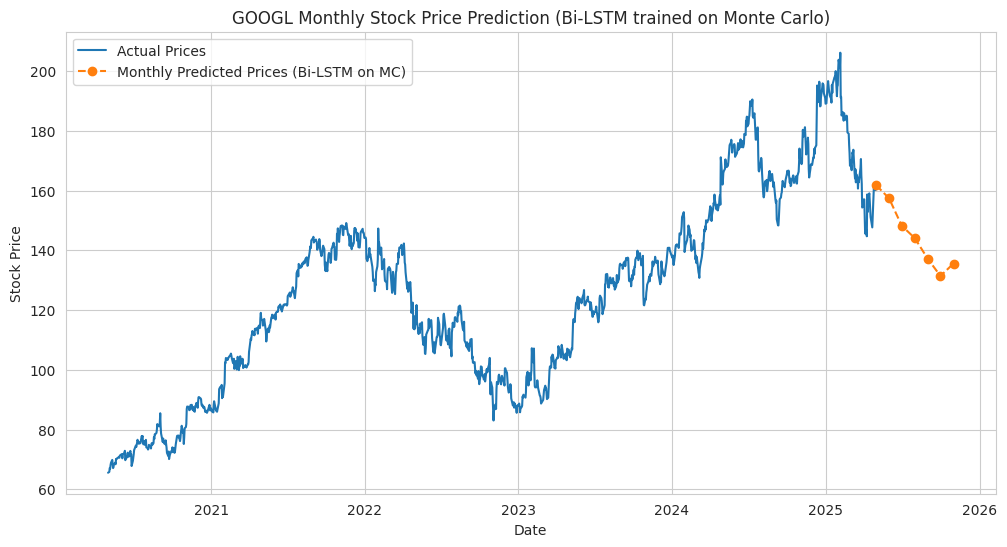

In [ ]:
predict_stock_price('GOOGL')

[*********************100%***********************]  1 of 1 completed
<ipython-input-154-ebf7ea2d59b7>:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  price_path[0] = last_price


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


178/178 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0279 - val_loss: 0.0132
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0092 - val_loss: 0.0121
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0088 - val_loss: 0.0122
Epoch 4/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0085 - val_loss: 0.0127
Epoch 5/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0085 - val_loss: 0.0128
Epoch 6/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0085 - val_loss: 0.0121
Epoch 7/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0085 - val_loss: 0.0122
Epoch 8/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0084 - val_loss: 0.0136
Epoch 9/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0083 - val_loss: 0.0133
Epoch 10/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0083 - val_loss: 0.0125
Epoch 11/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0081 - val_loss: 0.0133
Epoch 12/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/ste

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step


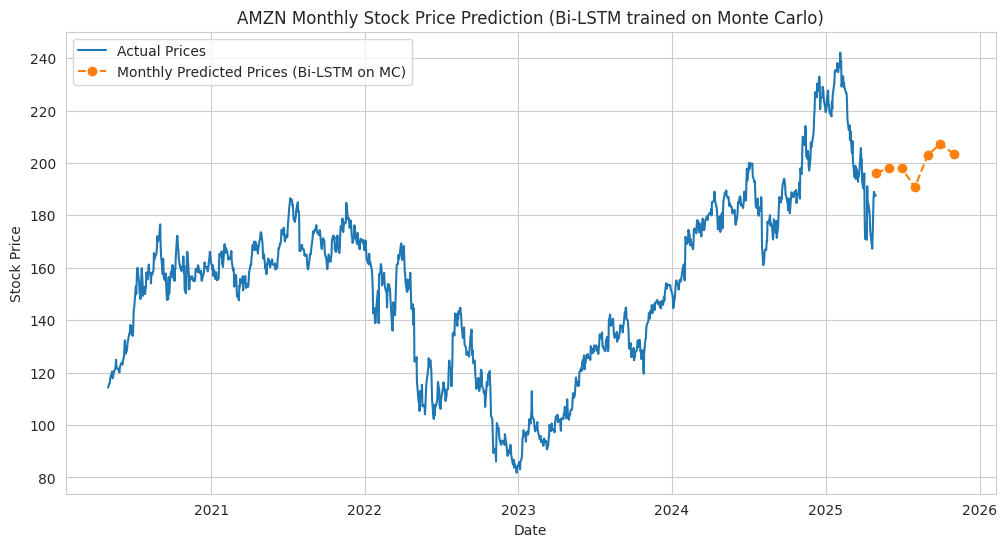

In [ ]:
predict_stock_price('AMZN')

[*********************100%***********************]  1 of 1 completed
<ipython-input-154-ebf7ea2d59b7>:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  price_path[0] = last_price
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0335 - val_loss: 0.0059
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0100 - val_loss: 0.0066
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0093 - val_loss: 0.0061
Epoch 4/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0093 - val_loss: 0.0059
Epoch 5/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0089 - val_loss: 0.0062
Epoch 6/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0089 - val_loss: 0.0060
Epoch 7/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0088 - val_loss: 0.0062
Epoch 8/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0085 - val_loss: 0.0059
Epoch 9/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0087 - val_loss: 0.0059
Epoch 10/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0085 - val_loss: 0.0059
Epoch 11/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0085 - val_loss: 0.0062
Epoch 12/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 

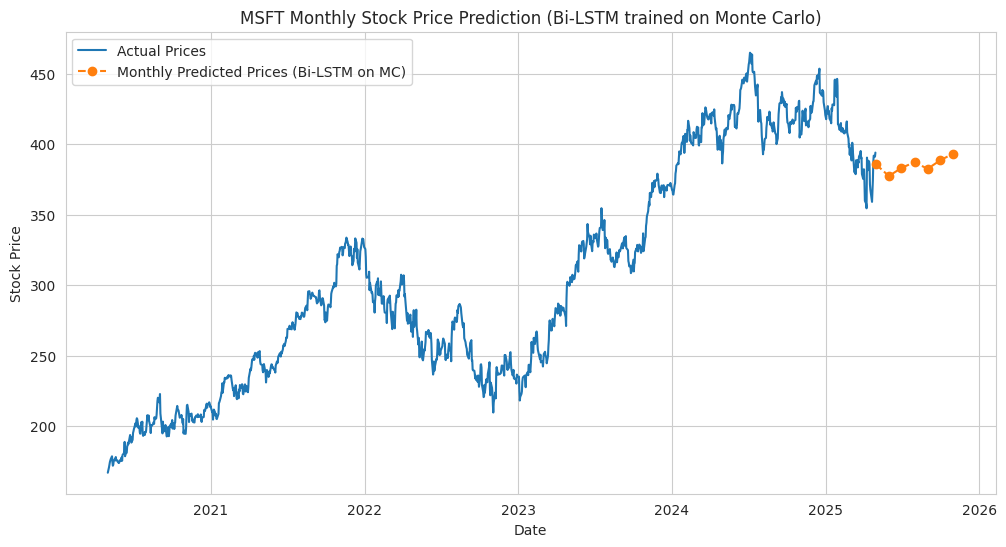

In [ ]:
predict_stock_price('MSFT')